In [7]:
"""
Comparacao Bayesiana global (dataset ANP).

Carrega o melhor experimento FM-MoE de cada horizonte e faz o merge com os
resultados dos modelos adicionais (UniTS e SimMTM). Esses dois modelos nao
dependem da configuracao do MoE, entao ficam em um diretorio proprio e valem
para qualquer experimento.
"""

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ========================
# ==== CONFIG ============
# ========================
BASE_RESULTS_PATH = "RESULTADOS_COMPLETOS_ANP/results_by_state_year"

# Modelos adicionais (UniTS, SimMTM). Mesma grade de arquivos
# results_<estado>_<ano>.csv por horizonte usada pelos demais modelos.
NEW_MODELS_PATH = "results_anp_novos_modelos/novos_models"

# Oráculo simples: para cada série, considera o MENOR erro entre os
# foundation models TimesFM, Chronos, Timer e Time-MoE (o modelo vencedor
# pode mudar de uma série para outra). "Chronos-Bolt-Small" é o nome com que
# o Chronos aparece em alguns CSVs.
ORACLE_NAME = "Oráculo Simples"
ORACLE_BASE_MODELS = ["TimesFM", "Chronos", "Chronos-Bolt-Small", "Timer", "Time-MoE"]


def add_simple_oracle(df, metric_cols, name=ORACLE_NAME, base_models=ORACLE_BASE_MODELS):
    """Anexa ao df a linha do oráculo simples: em cada série (coluna de
    métrica), o menor erro entre os modelos de base_models presentes no df.
    Se nenhum deles estiver no df (ex.: arquivo só com UniTS/SimMTM),
    retorna o df inalterado."""
    base = df[df["Modelo"].isin(base_models)]
    if base.empty or name in set(df["Modelo"]):
        return df
    if base["Modelo"].nunique() < 4:
        print(f"[ORÁCULO] apenas {sorted(base['Modelo'].unique())} disponíveis para o oráculo simples.")
    values = (
        base[metric_cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )
    oracle = values.min(axis=0).to_frame().T
    oracle.insert(0, "Modelo", name)
    return pd.concat([df, oracle], ignore_index=True)

# BEST_EXPERIMENTS = {
#     "horizon_3":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
#     "horizon_6":  "model_topk_2_norm_std_noise_True_ep_30_lr_0.001",
#     "horizon_12": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001",
#     "horizon_24": "model_topk_2_norm_std_noise_True_ep_100_lr_0.001"
# }

BEST_EXPERIMENTS = {
    "horizon_3":  "model_topk_1_norm_std_noise_True_ep_60_lr_0.001",
    "horizon_6":  "model_topk_1_norm_minmax_noise_True_ep_30_lr_0.001",
    "horizon_12": "model_topk_1_norm_minmax_noise_True_ep_100_lr_0.0001",
    "horizon_24": "model_topk_1_norm_minmax_noise_True_ep_100_lr_1e-05"
}


# Chaves que identificam uma observacao pareada: todos os modelos sao
# comparados na mesma celula (horizonte x estado x ano x derivado).
PAIR_KEYS = ["horizonte", "State", "Year", "Produto"]


# ========================
# ==== LOADER ============
# ========================
def load_horizon_folder(folder, horizon):
    """Le os results_<estado>_<ano>.csv de uma pasta horizon_* e devolve o
    formato longo (Modelo, Produto, MAPE, Year, State, horizonte)."""

    frames = []

    for file in sorted(os.listdir(folder)):

        if not file.endswith(".csv"):
            continue

        df = pd.read_csv(os.path.join(folder, file))

        # Oráculo simples: menor erro, por derivado, entre TimesFM/Chronos/Timer/Time-MoE
        product_cols = [c for c in df.columns
                        if c != "Modelo" and not str(c).startswith("Unnamed")]
        df = add_simple_oracle(df, product_cols)

        parts = file.replace(".csv", "").split("_")

        df_long = df.melt(
            id_vars=["Modelo"],
            var_name="Produto",
            value_name="MAPE"
        )

        df_long["Year"] = int(parts[-1])
        df_long["State"] = parts[-2].upper()
        df_long["horizonte"] = horizon

        frames.append(df_long)

    return pd.concat(frames, ignore_index=True) if frames else None


# ========================
# ==== LOAD & MERGE ======
# ========================
all_data = []

for horizon, experiment_name in BEST_EXPERIMENTS.items():

    # 1) modelos originais (melhor experimento daquele horizonte)
    exp_folder = os.path.join(BASE_RESULTS_PATH, experiment_name, horizon)

    if os.path.isdir(exp_folder):
        all_data.append(load_horizon_folder(exp_folder, horizon))
    else:
        print(f"[WARNING] experimento nao encontrado: {exp_folder}")

    # 2) modelos novos (UniTS, SimMTM)
    new_folder = os.path.join(NEW_MODELS_PATH, horizon)

    if os.path.isdir(new_folder):
        all_data.append(load_horizon_folder(new_folder, horizon))
    else:
        print(f"[WARNING] modelos novos nao encontrados: {new_folder}")

df_all = pd.concat([d for d in all_data if d is not None], ignore_index=True)


# ========================
# ==== CLEANUP ===========
# ========================
df_all = df_all[df_all["Produto"] != "Unnamed: 0"]

df_all["Modelo"] = df_all["Modelo"].replace({"Morai": "Moirai"})

df_all = (
    df_all
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["MAPE"])
)

# nenhum modelo pode aparecer duas vezes na mesma celula da grade
n_duplicated = df_all.duplicated(subset=PAIR_KEYS + ["Modelo"]).sum()

if n_duplicated:
    raise ValueError(
        f"{n_duplicated} linhas duplicadas em {PAIR_KEYS} + Modelo. "
        "Verifique se os resultados novos nao foram carregados duas vezes."
    )

print(f"[INFO] Registros carregados: {len(df_all)}")
print(f"[INFO] Horizontes: {sorted(df_all['horizonte'].unique())}")
print(f"[INFO] Modelos ({df_all['Modelo'].nunique()}): "
      f"{sorted(df_all['Modelo'].unique())}")


[INFO] Registros carregados: 73440
[INFO] Horizontes: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']
[INFO] Modelos (17): ['AutoARIMA', 'AutoETS', 'Chronos', 'Ensemble', 'FM-MoE', 'Moirai', 'NBEATS', 'PatchTST', 'RandomForest', 'SeasonalNaive', 'SimMTM', 'Time-MoE', 'Timer', 'TimesFM', 'UniTS', 'XGBRegressor', 'iTransformer']


In [8]:
target_products = [
    "Etanolhidratado",
    "Gasolinac",
    "Glp",
    "Oleodiesel",
    "Querosenedeaviacao"
]

df_all = df_all[df_all["Produto"].isin(target_products)]

print(df_all.head())

# ========================
# ==== COBERTURA =========
# ========================
n_cells = df_all[PAIR_KEYS].drop_duplicates().shape[0]

coverage = df_all.groupby("Modelo").size().sort_values(ascending=False)

print(f"\n[INFO] Celulas da grade (horizonte x estado x ano x derivado): {n_cells}")
print("\n[INFO] Observacoes por modelo:")
print(coverage.to_string())

incomplete = coverage[coverage < n_cells]

if len(incomplete):
    print("\n[WARNING] Modelos sem cobertura total da grade. As comparacoes "
          "pareadas usam somente as celulas em comum entre os dois modelos:")
    print(incomplete.to_string())


     Modelo          Produto     MAPE  Year State  horizonte
0  Time-MoE  Etanolhidratado  34.3143  2020    AC  horizon_3
1     Timer  Etanolhidratado  40.2342  2020    AC  horizon_3
2   TimesFM  Etanolhidratado  18.0751  2020    AC  horizon_3
3    Moirai  Etanolhidratado  35.5593  2020    AC  horizon_3
4   Chronos  Etanolhidratado  36.2043  2020    AC  horizon_3

[INFO] Celulas da grade (horizonte x estado x ano x derivado): 2700

[INFO] Observacoes por modelo:
Modelo
AutoARIMA        2700
SeasonalNaive    2700
XGBRegressor     2700
UniTS            2700
TimesFM          2700
Timer            2700
Time-MoE         2700
SimMTM           2700
RandomForest     2700
AutoETS          2700
PatchTST         2700
NBEATS           2700
Moirai           2700
FM-MoE           2700
Ensemble         2700
Chronos          2700
iTransformer     2700


In [9]:
# ================================================
#  IMPORTS
# ================================================
import numpy as np
import pandas as pd
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt


# ================================================
#  CONFIG
# ================================================
ROPE = 0.5                  # 0.5 p.p. de MAPE
RANDOM_SEED = 42
N_POSTERIOR_SAMPLES = 5000


# ================================================
#  1. BAYESIAN SIGNED-RANK TEST
# ================================================
def bayesian_signed_rank(differences, rope=ROPE, s=0.5, rng=None):
    """
    Bayesian Signed-Rank Test.

    differences : diferencas pareadas (B - A); positivo => A tem erro menor
    rope        : regiao de equivalencia pratica (0.5 = 0.5 p.p. de MAPE)
    s           : pseudo-contagem do prior de Dirichlet (0.5 recomendado)
    rng         : gerador numpy (deixa o resultado reprodutivel)
    """

    diffs = np.asarray(differences, dtype=float)

    n_left  = np.sum(diffs < -rope)          # B e melhor
    n_rope  = np.sum(np.abs(diffs) <= rope)  # equivalentes
    n_right = np.sum(diffs > rope)           # A e melhor

    alpha = np.array([n_left + s, n_rope + s, n_right + s])

    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)

    posterior = rng.dirichlet(alpha, size=N_POSTERIOR_SAMPLES)

    theta_left, theta_rope, theta_right = posterior.mean(axis=0)

    return theta_left, theta_rope, theta_right


# ================================================
#  2. PAREAMENTO POR CHAVE
# ================================================
def build_pair_table(df, metric="MAPE"):
    """Tabela (celula da grade) x (modelo).

    Garante que a comparacao entre dois modelos use exatamente as mesmas
    celulas (horizonte, estado, ano, derivado), independentemente da ordem
    em que os arquivos foram lidos ou de quantos modelos existem em cada
    diretorio - necessario agora que UniTS e SimMTM vem de outra pasta.
    """

    return df.pivot_table(
        index=PAIR_KEYS,
        columns="Modelo",
        values=metric,
        aggfunc="mean"
    )


def paired_differences(pair_table, A, B):
    """Diferencas B - A nas celulas em que os dois modelos existem."""

    pair = pair_table[[A, B]].dropna()

    return (pair[B] - pair[A]).to_numpy()


# ================================================
#  3. MATRIZ DE COMPARACAO BAYESIANA
# ================================================
def bayesian_matrix(df, rope=ROPE, metric="MAPE"):

    pair_table = build_pair_table(df, metric)

    models = sorted(pair_table.columns)

    mat_better = pd.DataFrame(0.0, index=models, columns=models)
    mat_rope   = pd.DataFrame(0.0, index=models, columns=models)

    rng = np.random.default_rng(RANDOM_SEED)

    for A, B in combinations(models, 2):

        # Menor erro = modelo melhor
        diffs = paired_differences(pair_table, A, B)

        if len(diffs) == 0:
            raise ValueError(f"Nenhuma celula em comum entre {A} e {B}.")

        theta_left, theta_rope, theta_right = bayesian_signed_rank(
            diffs, rope, rng=rng
        )

        mat_better.loc[A, B] = theta_right
        mat_better.loc[B, A] = theta_left

        mat_rope.loc[A, B] = theta_rope
        mat_rope.loc[B, A] = theta_rope

    return mat_better, mat_rope


# ================================================
#  4. PLOT DA MATRIZ
# ================================================
def plot_bayesian_matrix(matrix, title=""):

    plt.figure(figsize=(12, 9))

    ax = sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        annot_kws={"fontsize": 8},
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=True
    )

    ax.set_title(title, fontsize=15, pad=20)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


Computing Bayesian comparisons...

P(FM-MoE supera o modelo B) - rope = 0.5%

        AutoARIMA  AutoETS  Chronos  Ensemble  Moirai  NBEATS  PatchTST  RandomForest  SeasonalNaive  SimMTM  Time-MoE  Timer  TimesFM  UniTS  XGBRegressor  iTransformer
H = 3       0.545    0.562    0.386     0.468   0.611   0.854     0.551         0.613          0.652   0.537     0.393  0.449    0.291  0.651         0.629         0.556
H = 6       0.618    0.665    0.392     0.477   0.664   0.911     0.505         0.623          0.615   0.551     0.428  0.452    0.280  0.653         0.672         0.539
H = 12      0.635    0.691    0.351     0.417   0.700   0.854     0.562         0.530          0.561   0.506     0.586  0.438    0.289  0.740         0.586         0.600
H = 24      0.602    0.635    0.412     0.426   0.666   0.913     0.547         0.518          0.536   0.589     0.669  0.511    0.344  0.762         0.595         0.555

Generating plot...



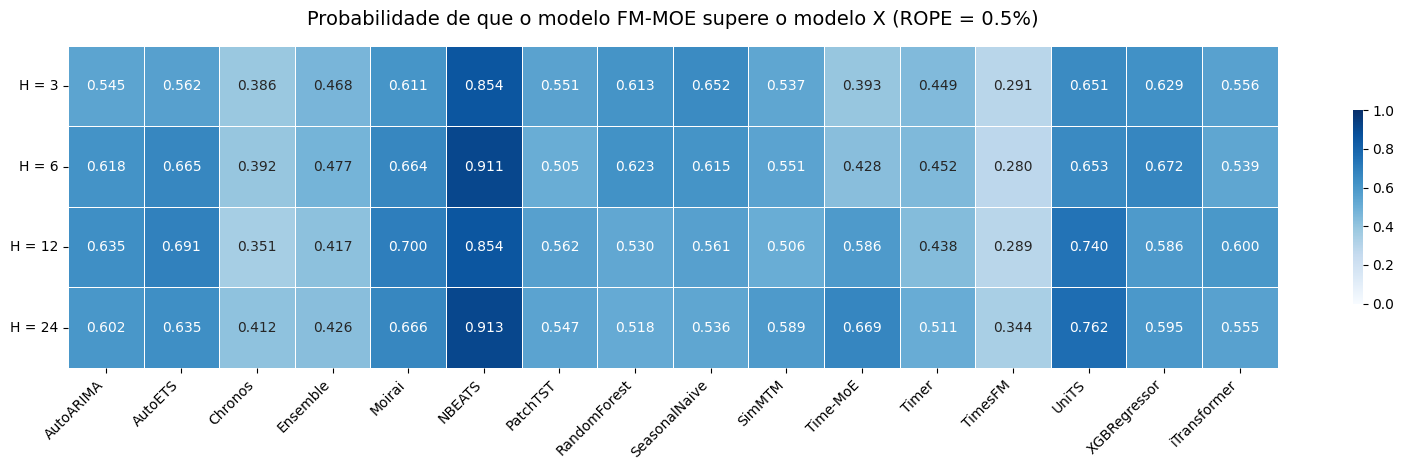

In [ ]:
"""
Heatmap Bayesiano do FM-MoE contra cada modelo concorrente, uma linha por
horizonte.

Mesmo estilo do heatmap do notebook de benchmark (sns.heatmap, colormap
azul, linhas brancas, colorbar encolhida).
"""

REFERENCE_MODEL = "FM-MoE"

HORIZON_ORDER = ["horizon_3", "horizon_6", "horizon_12", "horizon_24"]

# Foundation models primeiro, modelos novos ao final.
COLUMN_ORDER = [
    "AutoARIMA",
    "AutoETS",
    "Chronos",
    "Ensemble",
    "Moirai",
    "NBEATS",
    "PatchTST",
    "RandomForest",
    "SeasonalNaive",
    "SimMTM",
    "Time-MoE",
    "Timer",
    "TimesFM",
    "UniTS",
    "XGBRegressor",
    "iTransformer",
    ORACLE_NAME,  # menor erro por série entre TimesFM, Chronos, Timer e Time-MoE
]

available_models = set(df_all["Modelo"].unique())

horizons = [h for h in HORIZON_ORDER if h in set(df_all["horizonte"].unique())]
models = [m for m in COLUMN_ORDER if m in available_models]

missing = [m for m in COLUMN_ORDER if m not in available_models]

if missing:
    print(f"[WARNING] modelos ausentes nos resultados carregados: {missing}")


# ================================================
#  1. MATRIZ (horizontes x modelos)
# ================================================
def build_horizon_matrix(df_all, my_model, models, horizons,
                         rope=ROPE, metric="MAPE"):
    """P(my_model supera o modelo B), uma linha por horizonte."""

    rng = np.random.default_rng(RANDOM_SEED)

    rows = {}

    for horizon in horizons:

        pair_table = build_pair_table(df_all[df_all["horizonte"] == horizon],
                                      metric)

        row_label = f"H = {horizon.split('_')[-1]}"
        rows[row_label] = {}

        for model in models:

            diffs = paired_differences(pair_table, my_model, model)

            _, _, theta_right = bayesian_signed_rank(diffs, rope, rng=rng)

            rows[row_label][model] = theta_right

    # mantem a ordem de COLUMN_ORDER / HORIZON_ORDER
    return pd.DataFrame(rows).T[models]


# ================================================
#  2. PLOT
# ================================================
def plot_combined_heatmap(matrix, my_model, rope=ROPE):
    n_rows = len(matrix)
    n_cols = len(matrix.columns)

    fig, ax = plt.subplots(figsize=(max(14, n_cols * 1.0), max(4, n_rows * 0.7 + 2)))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar=True,
        cbar_kws={"shrink": 0.6},
        ax=ax
    )

    ax.set_title(
        f"Probabilidade de que o modelo {my_model.upper()} supere o modelo X "
        f"(ROPE = {rope}%)",
        fontsize=14, pad=15
    )
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()


# =============================================================
#  3. RUN
# =============================================================
print("Computing Bayesian comparisons...")

df_heatmap = build_horizon_matrix(
    df_all, REFERENCE_MODEL, models, horizons, rope=ROPE, metric="MAPE"
)

print(f"\nP({REFERENCE_MODEL} supera o modelo B) - rope = {ROPE}%\n")
print(df_heatmap.round(3).to_string())

print("\nGenerating plot...\n")
plot_combined_heatmap(df_heatmap, REFERENCE_MODEL, rope=ROPE)

Computing Bayesian comparison matrices...
Generating plots...



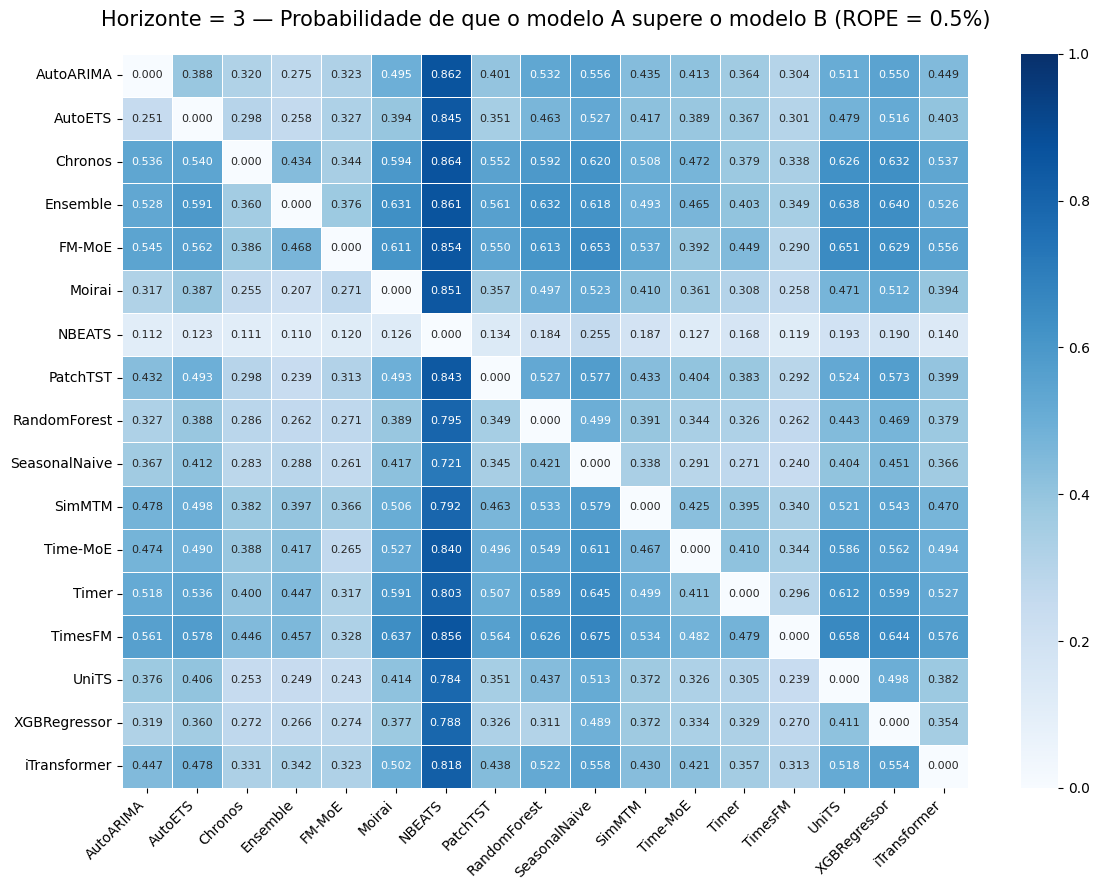

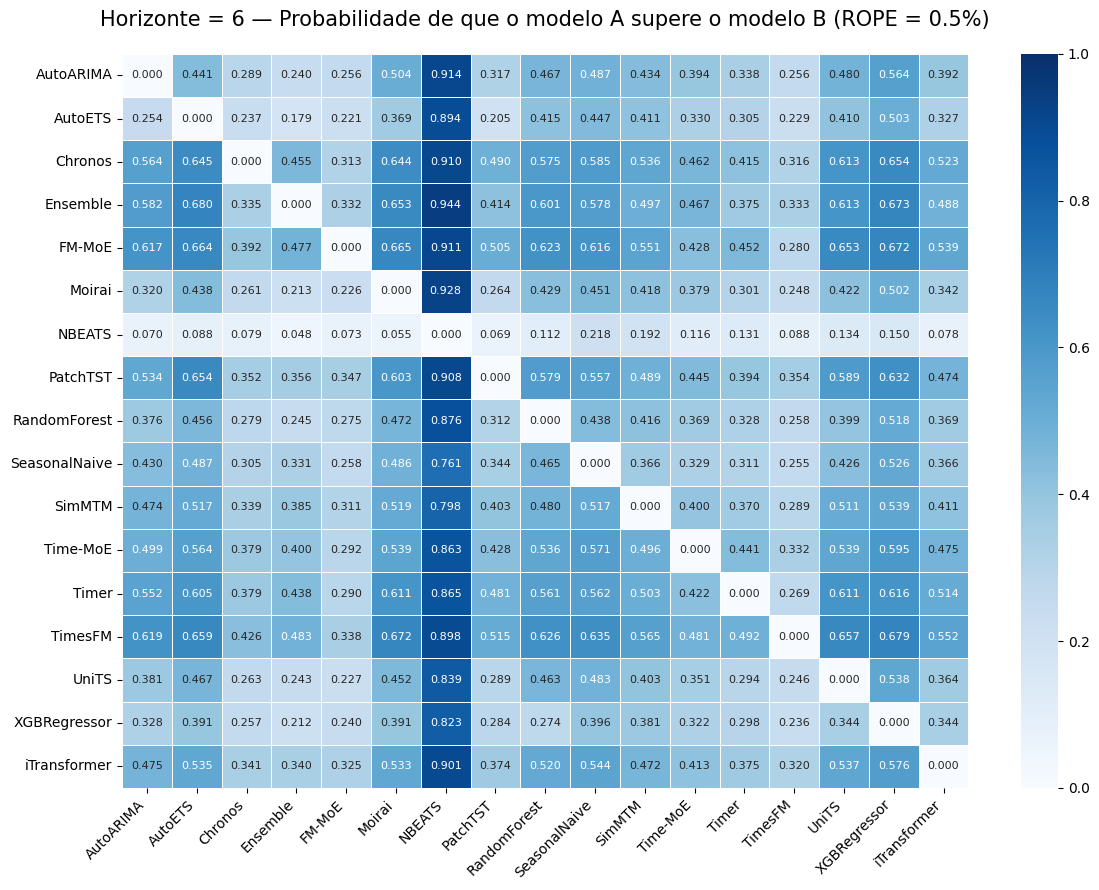

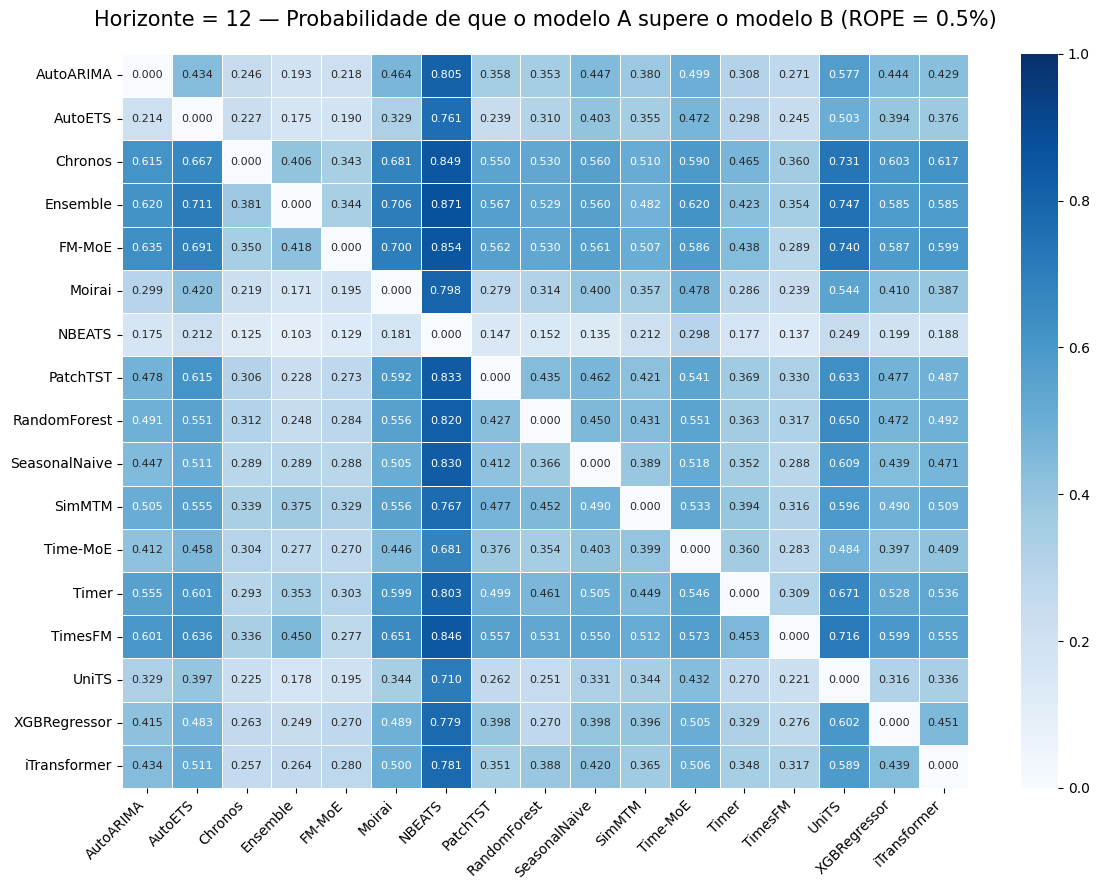

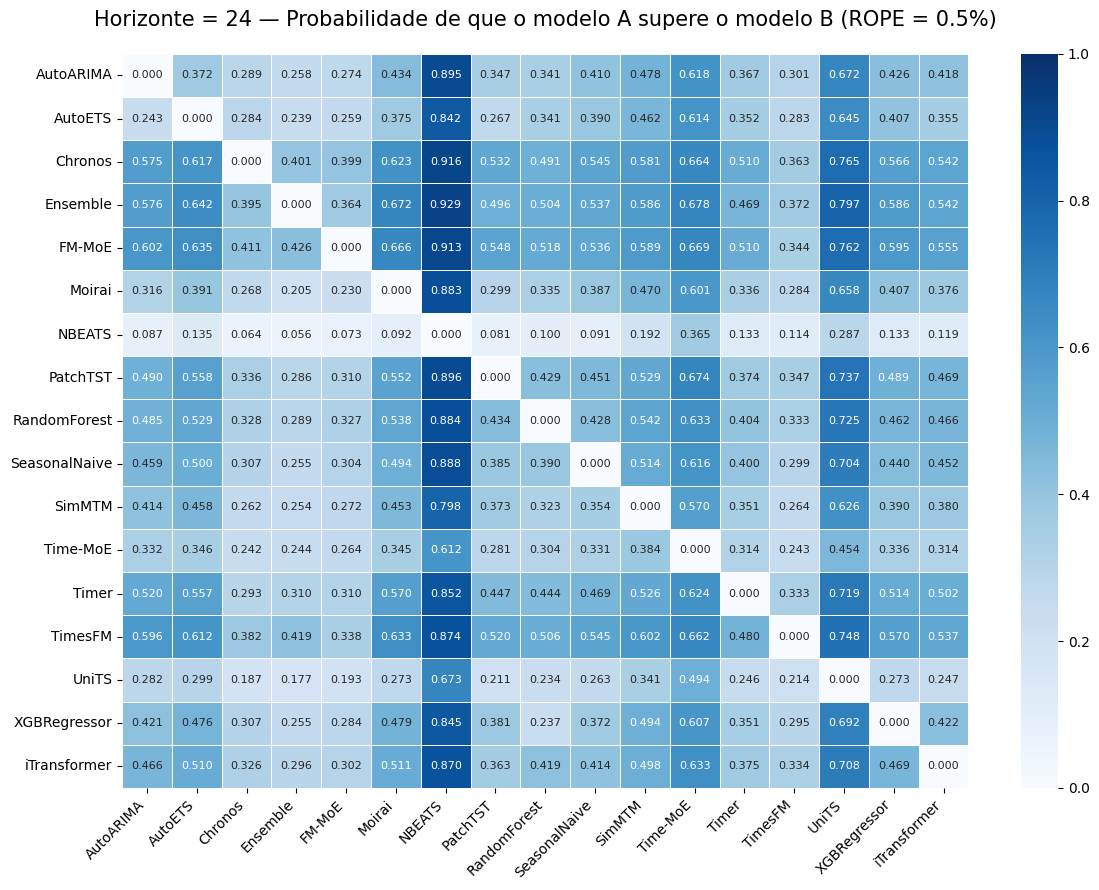

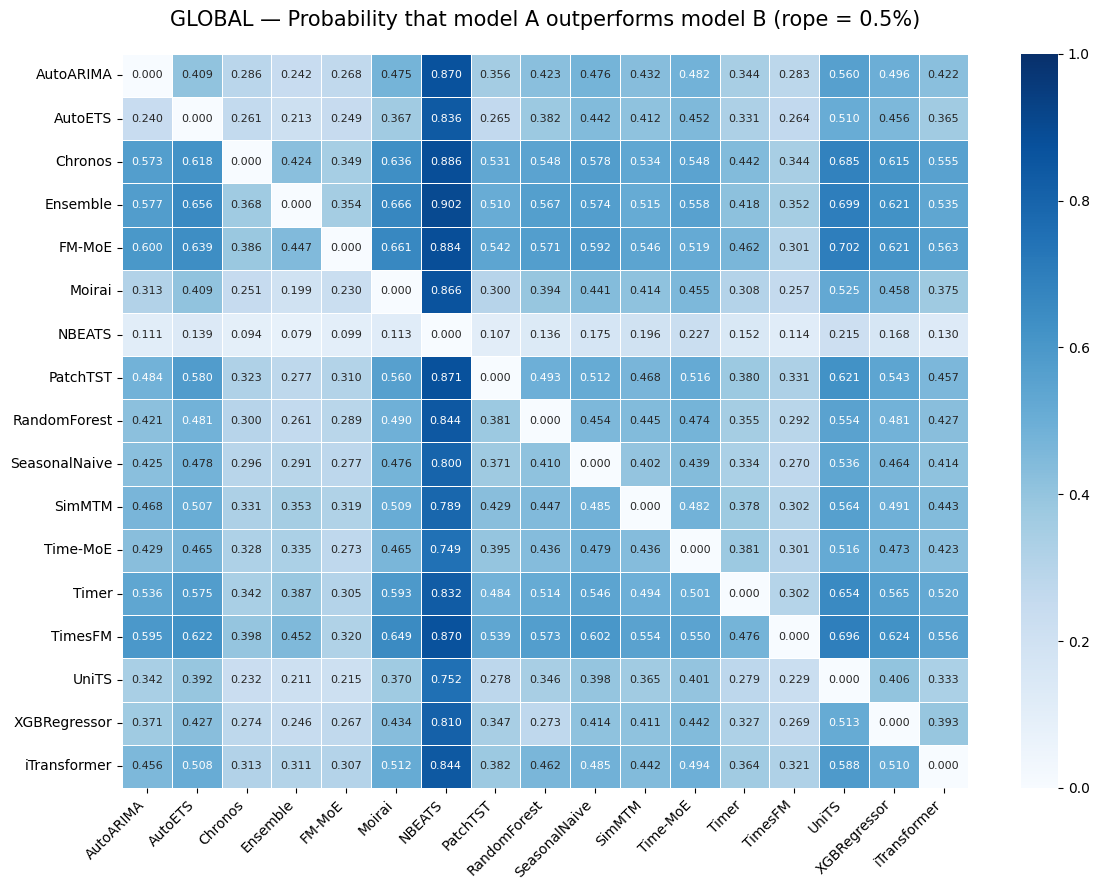

In [10]:
# =============================================================
#  MATRIZES BAYESIANAS COMPLETAS (todos os modelos, par a par)
# =============================================================
def run_bayesian_tests_by_horizon_and_global(df_all, rope=ROPE, metric="MAPE"):

    results = {}

    # A) POR HORIZONTE
    horizons = [h for h in HORIZON_ORDER if h in set(df_all["horizonte"].unique())]

    for horizon in horizons:

        subset = df_all[df_all["horizonte"] == horizon]

        if subset["Modelo"].nunique() > 1:

            mat_better, mat_rope = bayesian_matrix(subset, rope, metric)

            results[("HORIZON", horizon)] = {
                "matrix_better": mat_better,
                "matrix_rope": mat_rope
            }

    # B) GLOBAL
    if df_all["Modelo"].nunique() > 1:

        mat_better, mat_rope = bayesian_matrix(df_all, rope, metric)

        results[("GLOBAL", "ALL_HORIZONS")] = {
            "matrix_better": mat_better,
            "matrix_rope": mat_rope
        }

    return results


print("Computing Bayesian comparison matrices...")

results = run_bayesian_tests_by_horizon_and_global(
    df_all,
    rope=ROPE,
    metric="MAPE"
)

print("Generating plots...\n")

for key, res in results.items():

    category, value = key

    if category == "GLOBAL":

        title = (f"GLOBAL — Probability that model A outperforms model B "
                 f"(rope = {ROPE}%)")

    else:

        # Converte "horizon_12" -> 12
        horizon_number = str(value).split("_")[-1]

        title = (f"Horizonte = {horizon_number} — Probabilidade de que o modelo A "
                 f"supere o modelo B (ROPE = {ROPE}%)")

    plot_bayesian_matrix(res["matrix_better"], title)


In [6]:
# =============================================================
#  RANKING DE EXPERIMENTOS DO FM-MoE
#  (varre todos os experimentos; UniTS e SimMTM entram como
#   concorrentes adicionais em todos eles)
#
#  O ranking e separado por horizonte E por topk: top-1 e top-2
#  nao competem entre si, cada um tem o seu proprio TOP 5.
# =============================================================
import re

MY_MOE_NAME = "FM-MoE"
TOP_K = 5


def parse_topk(experiment_name):
    """Extrai o topk do nome do experimento (model_topk_2_... -> 2)."""

    match = re.search(r"topk_(\d+)", experiment_name)

    return int(match.group(1)) if match else None


# -------------------------------------------------------------
# Modelos novos: carregados uma unica vez, pois nao dependem da
# configuracao do MoE - o mesmo resultado vale para todo experimento.
# -------------------------------------------------------------
new_models_by_horizon = {}

for horizon_folder in sorted(os.listdir(NEW_MODELS_PATH)):

    folder = os.path.join(NEW_MODELS_PATH, horizon_folder)

    if "horizon" not in horizon_folder or not os.path.isdir(folder):
        continue

    new_models_by_horizon[horizon_folder] = load_horizon_folder(
        folder, horizon_folder
    )

new_model_names = sorted(
    pd.concat(new_models_by_horizon.values())["Modelo"].unique()
)

print(f"[INFO] Modelos novos incluidos na varredura: {new_model_names}")
print(f"[INFO] Horizontes com modelos novos: {sorted(new_models_by_horizon)}\n")


# -------------------------------------------------------------
# PROCESSAMENTO
# -------------------------------------------------------------
rng_sweep = np.random.default_rng(RANDOM_SEED)

results_by_horizon = {}

for experiment_name in sorted(os.listdir(BASE_RESULTS_PATH)):

    experiment_path = os.path.join(BASE_RESULTS_PATH, experiment_name)

    if not os.path.isdir(experiment_path):
        continue

    topk = parse_topk(experiment_name)

    if topk is None:
        print(f"[SKIP] experimento sem topk identificavel: {experiment_name}")
        continue

    # cada experimento possui horizon_x
    for horizon_folder in sorted(os.listdir(experiment_path)):

        if "horizon" not in horizon_folder:
            continue

        horizon_path = os.path.join(experiment_path, horizon_folder)

        df_exp = load_horizon_folder(horizon_path, horizon_folder)

        if df_exp is None:
            continue

        # merge com UniTS / SimMTM do mesmo horizonte
        frames = [df_exp]

        if horizon_folder in new_models_by_horizon:
            frames.append(new_models_by_horizon[horizon_folder])
        else:
            print(f"[WARNING] sem modelos novos para {horizon_folder}")

        df_h = pd.concat(frames, ignore_index=True)

        df_h["Modelo"] = df_h["Modelo"].replace({"Morai": "Moirai"})

        df_h = (
            df_h
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["MAPE"])
        )

        df_h = df_h[df_h["Produto"].isin(target_products)]

        pair_table = build_pair_table(df_h)

        if MY_MOE_NAME not in pair_table.columns:
            continue

        row = {
            "Experimento": experiment_name,
            "Horizon": horizon_folder,
            "TopK": topk
        }

        probs = []

        for other_model in pair_table.columns:

            if other_model == MY_MOE_NAME:
                continue

            diffs = paired_differences(pair_table, MY_MOE_NAME, other_model)

            _, _, p = bayesian_signed_rank(diffs, ROPE, rng=rng_sweep)

            row[f"Prob_MyMoE_vs_{other_model}"] = p
            probs.append(p)

        row["Score_Medio_MyMoE"] = np.mean(probs)

        results_by_horizon.setdefault(horizon_folder, []).append(row)


# -------------------------------------------------------------
# RANKING POR HORIZONTE E POR TOPK
# -------------------------------------------------------------
print("\n")

for horizon in [h for h in HORIZON_ORDER if h in results_by_horizon]:

    df_h = pd.DataFrame(results_by_horizon[horizon])

    for topk in sorted(df_h["TopK"].unique()):

        df_k = (
            df_h[df_h["TopK"] == topk]
            .sort_values("Score_Medio_MyMoE", ascending=False)
            .reset_index(drop=True)
        )

        if df_k.empty:
            continue

        # Horizonte e topk ja estao no cabecalho -> tabela mais enxuta
        df_show = df_k.drop(columns=["Horizon", "TopK"])

        print("=" * 80)
        print(f"TOP {TOP_K} EXPERIMENTOS — {horizon} | topk = {topk}")
        print("=" * 80)

        print(df_show.head(TOP_K).to_string(index=False))
        print("\n")

        melhor = df_k.loc[0, "Experimento"]
        configurado = BEST_EXPERIMENTS.get(horizon)

        # So compara com o BEST_EXPERIMENTS quando o topk configurado
        # e o mesmo deste bloco do ranking.
        if configurado and parse_topk(configurado) == topk and melhor != configurado:
            print(f"[ATENCAO] BEST_EXPERIMENTS[{horizon!r}] = {configurado!r}, "
                  f"mas o melhor da varredura (topk = {topk}) e {melhor!r}.\n")

[INFO] Modelos novos incluidos na varredura: ['SimMTM', 'UniTS']
[INFO] Horizontes com modelos novos: ['horizon_12', 'horizon_24', 'horizon_3', 'horizon_6']



TOP 5 EXPERIMENTOS — horizon_3 | topk = 1
                                       Experimento  Prob_MyMoE_vs_AutoARIMA  Prob_MyMoE_vs_AutoETS  Prob_MyMoE_vs_Chronos  Prob_MyMoE_vs_Ensemble  Prob_MyMoE_vs_Moirai  Prob_MyMoE_vs_NBEATS  Prob_MyMoE_vs_PatchTST  Prob_MyMoE_vs_RandomForest  Prob_MyMoE_vs_SeasonalNaive  Prob_MyMoE_vs_SimMTM  Prob_MyMoE_vs_Time-MoE  Prob_MyMoE_vs_Timer  Prob_MyMoE_vs_TimesFM  Prob_MyMoE_vs_UniTS  Prob_MyMoE_vs_XGBRegressor  Prob_MyMoE_vs_iTransformer  Score_Medio_MyMoE
   model_topk_1_norm_std_noise_True_ep_60_lr_0.001                 0.544615               0.562085               0.386810                0.467847              0.610950              0.853486                0.550725                    0.612602                     0.652575              0.537342                0.392580             0.448535    